In [7]:
# 1. Install necessary libraries
!pip install yfinance pandas_ta gymnasium stable-baselines3 shimmy

import gymnasium as gym
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from gymnasium import spaces

# 2. Data Collection (NIFTY 50 - using a subset for speed)
# We'll use RELIANCE, HDFCBANK, and TCS as representatives
tickers = ["RELIANCE.NS", "HDFCBANK.NS", "TCS.NS"]
data = yf.download(tickers, start="2010-01-01", end="2019-12-31")['Close']

/tmp/ipython-input-2878558127.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01", end="2019-12-31")['Close']
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow()

In [8]:
# 3. Preprocessing & Indicators
def add_indicators(df):
    indicators = pd.DataFrame(index=df.index)
    for col in df.columns:
        indicators[f'{col}_RSI'] = ta.rsi(df[col], length=14)
        macd = ta.macd(df[col])
        indicators[f'{col}_MACD'] = macd['MACD_12_26_9']
        indicators[f'{col}_CCI'] = ta.cci(df[col], df[col], df[col], length=14)

        indicators[f'{col}_ADX'] = ta.adx(df[col], df[col], df[col], length=14)['ADX_14']

    return indicators.fillna(0)

indicators = add_indicators(data)
prices = data.values
indicator_values = indicators.values

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# 4. Custom Trading Environment
class StockTradingEnv(gym.Env):
    def __init__(self, prices, indicators, initial_balance=100000):
        super(StockTradingEnv, self).__init__()
        self.prices = prices
        self.indicators = indicators
        self.initial_balance = initial_balance

        # Action: Buy(0), Sell(1), Hold(2) for each stock
        self.action_space = spaces.MultiDiscrete([3] * prices.shape[1])

        # State: Balance + Shares + Prices + Indicators
        state_dim = 1 + prices.shape[1] + prices.shape[1] + indicators.shape[1]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(state_dim,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.shares = np.zeros(self.prices.shape[1])
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        obs = np.concatenate([
            [self.balance],
            self.shares,
            self.prices[self.current_step],
            self.indicators[self.current_step]
        ])
        return obs.astype(np.float32)

    def step(self, actions):
        prev_portfolio_value = self.balance + np.sum(self.shares * self.prices[self.current_step])
        transaction_costs = 0

        for i, action in enumerate(actions):
            price = self.prices[self.current_step]
            if action == 0: # Buy
                num_to_buy = self.balance // price[i]
                if num_to_buy > 0:
                    cost = num_to_buy * price[i]
                    tx_fee = cost * 0.001
                    self.shares[i] += num_to_buy
                    self.balance -= (cost + tx_fee)
                    transaction_costs += tx_fee
            elif action == 1: # Sell
                if self.shares[i] > 0:
                    gain = self.shares[i] * price[i]
                    tx_fee = gain * 0.001
                    self.balance += (gain - tx_fee)
                    self.shares[i] = 0
                    transaction_costs += tx_fee

        self.current_step += 1
        done = self.current_step >= len(self.prices) - 1

        current_portfolio_value = self.balance + np.sum(self.shares * self.prices[self.current_step])
        reward = (current_portfolio_value - prev_portfolio_value) - transaction_costs

        return self._get_obs(), reward, done, False, {}

In [10]:
# 5. Training
env = StockTradingEnv(prices, indicator_values)
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000) # Fast training for the demo

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 201  |
|    iterations      | 1    |
|    time_elapsed    | 10   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 2.46e+03     |
|    ep_rew_mean          | -8.89e+04    |
| time/                   |              |
|    fps                  | 233          |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0037992764 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.29        |
|    explained_variance   | 4.71e-06     |
|    learning_rate        | 0.0003       |
|    lo

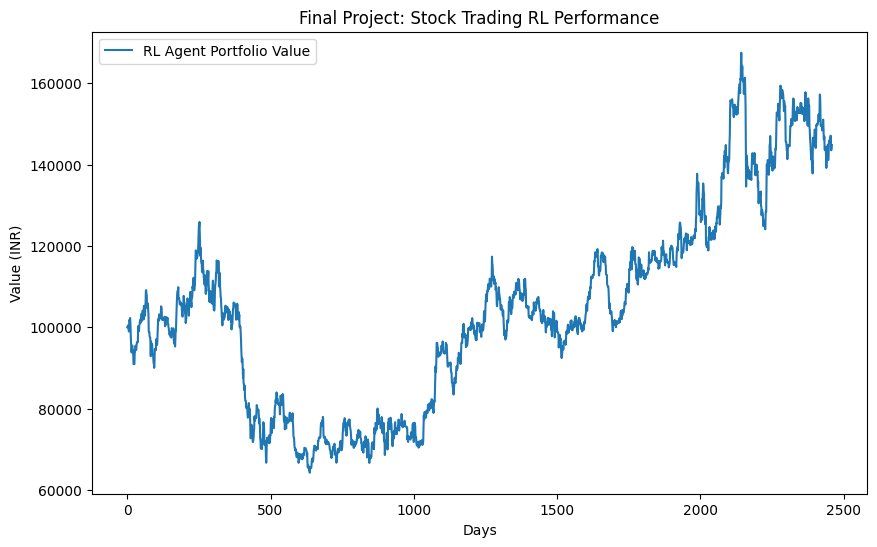

In [11]:
# 6. Evaluation & Plotting
obs, _ = env.reset()
portfolio_values = []
for _ in range(len(prices)-1):
    action, _ = model.predict(obs)
    obs, reward, done, _, _ = env.step(action)
    portfolio_values.append(env.balance + np.sum(env.shares * env.prices[env.current_step]))

plt.figure(figsize=(10,6))
plt.plot(portfolio_values, label='RL Agent Portfolio Value')
plt.title('Final Project: Stock Trading RL Performance')
plt.xlabel('Days')
plt.ylabel('Value (INR)')
plt.legend()
plt.show()

In [12]:
# Cumulative Return
final_value = portfolio_values[-1]
initial_value = portfolio_values[0]
cumulative_return = ((final_value - initial_value) / initial_value) * 100

# Annualized Sharpe Ratio
returns = np.diff(portfolio_values) / portfolio_values[:-1]
sharpe_ratio = (np.mean(returns) / np.std(returns)) * np.sqrt(252) if np.std(returns) != 0 else 0

print(f"Total Cumulative Return: {cumulative_return:.2f}%")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")

Total Cumulative Return: 44.85%
Annualized Sharpe Ratio: 0.29
